# Workshop: Tunix-Med · Part 4: Final Evaluation & Proof of Knowledge

In this final notebook, we prove the effectiveness of our SFT training by evaluating the
**Fine-Tuned Gemma 3 1B** using the exact same criteria as the baseline.

### Fixes applied vs the original version
- `torch_dtype` kwarg is deprecated → replaced with `dtype`.
- Perplexity label mask was broken (`full.clone().where(full == ref, -100)` raises a
  size-mismatch RuntimeError).  Fixed to mask by prompt length, identical to notebook 02.
- Calibration block simplified (no silent `except` swallowing errors).


## 0 · Load Fine-Tuned Model

In [1]:
import os
import warnings
import logging
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# Silence unnecessary logs
warnings.filterwarnings("ignore")
logging.getLogger("httpx").setLevel(logging.WARNING)
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def info_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = info_device()
# Use bfloat16 on Ampere+ (A100, H100, Grace Hopper …) – this includes the DGX Spark.
dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
    else torch.float32
)
print(f"Device: {device}  |  dtype: {dtype}")

BASE_MODEL = "google/gemma-3-270m-it"
ADAPTER_PATH = "lmassaron/gemma-3-1b-medical-cardiology-lora"

print(f"Loading base model and merging adapter from {ADAPTER_PATH}...")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, dtype=dtype, device_map=device
)

model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model = model.merge_and_unload()
model.eval()
print("Fine-tuned model merged and ready.")

Device: cuda  |  dtype: torch.bfloat16
Loading base model and merging adapter from lmassaron/gemma-3-1b-medical-cardiology-lora...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 6.0.3+68b436d
Transformers : 5.5.4
Torch        : 2.11.0+cu130
Triton       : 3.6.0


Fine-tuned model merged and ready.


## 1 · Reconstructing the Test Set (identical sampling to notebook 02)

In [2]:
DATASET_ID, EVAL_SPLIT, SEED, N_EVAL_QS = (
    "lmassaron/medical-cardiology-qa",
    0.1,
    42,
    30,
)
full_ds = load_dataset(DATASET_ID, split="train")
rng = np.random.default_rng(SEED)
all_idx = rng.permutation(len(full_ds))
eval_idx = all_idx[int(len(full_ds) * (1.0 - EVAL_SPLIT)) :]


def extract_qa(example):
    msgs = example["messages"]
    return {
        "question": next(m["content"] for m in msgs if m["role"] == "user"),
        "answer": next(m["content"] for m in msgs if m["role"] == "assistant"),
    }


rng2, seen_prefixes, qa_pairs = np.random.default_rng(SEED + 1), set(), []
for idx in rng2.permutation(eval_idx):
    if len(qa_pairs) >= N_EVAL_QS:
        break
    ex = extract_qa(full_ds[int(idx)])
    q, a = ex["question"], ex["answer"]
    if len(a) < 25:
        continue
    prefix = " ".join(q.lower().split()[:4])
    if prefix in seen_prefixes:
        continue
    seen_prefixes.add(prefix)
    qa_pairs.append({"question": q, "answer": a, "dataset_idx": int(idx)})

data = pd.DataFrame(qa_pairs)
print(f"Sampled {len(data)} questions for final testing.")

Sampled 30 questions for final testing.


## 2 · Final Inference & Fixed Perplexity

**Bug fix**: the original code computed `full.clone().where(full == ref, -100)` which
raises `RuntimeError: The size of tensor a (N) must match the size of tensor b (M)`
because `full` and `ref` have different sequence lengths.

The correct approach (matching notebook 02) is to mask by prompt length:

```python
labels = full_ids.clone()
labels[:, :prompt_len] = -100   # ignore prompt; only score the answer
```


In [3]:
import re
import os

SYSTEM_PROMPT = (
    "You are a knowledgeable medical assistant specializing in cardiology. "
    "Answer clinical questions accurately, focusing on diagnostic criteria, "
    "treatment guidelines, and pathophysiology."
)
results_list = []

for _, row in tqdm(data.iterrows(), total=len(data)):
    # ── Generation ─────────────────────────────────────────────────────────
    encoded = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["question"]},
        ],
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    prompt_len = encoded["input_ids"].shape[-1]

    with torch.no_grad():
        out = model.generate(
            **encoded,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,
        )
    gen = tokenizer.decode(out[0, prompt_len:], skip_special_tokens=True).strip()

    # ── Perplexity (fixed label mask) ───────────────────────────────────────
    ref_ids = tokenizer(
        row["answer"], return_tensors="pt", add_special_tokens=False
    ).input_ids.to(device)

    full_ids = torch.cat([encoded["input_ids"], ref_ids], dim=1)
    labels = full_ids.clone()
    labels[:, :prompt_len] = -100  # ← correct: mask only by prompt length

    with torch.no_grad():
        loss = model(full_ids, labels=labels).loss
    perplexity = torch.exp(loss).item()

    results_list.append(
        {
            "question": row["question"],
            "expected_answer": row["answer"],
            "generated_answer": gen,
            "perplexity": perplexity,
        }
    )

results_df = pd.DataFrame(results_list)
print(f"Inference complete. Mean perplexity: {results_df['perplexity'].mean():.2f}")

  0%|          | 0/30 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Inference complete. Mean perplexity: 14.47


## 3 · Scoring (identical to baseline)

We use the **fixed calibration range** from the baseline notebook.  If you ran notebook 02
and saved `medical_baseline_results.csv`, we read the range from there; otherwise we use
the known 270M baseline values.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Keyword F1 with TF-IDF Weights
# ---------------------------------
# We fit TF-IDF on the whole eval set to identify rare, important medical words.
_tfidf = TfidfVectorizer(
    analyzer="word", token_pattern=r"\b\w{4,}\b", sublinear_tf=True
)
_tfidf.fit(results_df["expected_answer"].tolist())
_vocab = _tfidf.vocabulary_
_idf = _tfidf.idf_


def keyword_f1_tfidf(generated: str, expected: str) -> float:
    ref_kws = set(re.findall(r"\b\w{4,}\b", expected.lower()))
    gen_kws = set(re.findall(r"\b\w{4,}\b", generated.lower()))
    if not ref_kws:
        return 1.0

    def weighted_count(kws, universe):
        return sum(
            _idf[_vocab[w]] if w in _vocab else 1.0 for w in universe if w in kws
        )

    ref_weight = sum(_idf[_vocab[w]] if w in _vocab else 1.0 for w in ref_kws)
    gen_weight = (
        sum(_idf[_vocab[w]] if w in _vocab else 1.0 for w in gen_kws)
        if gen_kws
        else 0.0
    )

    if ref_weight == 0 or gen_weight == 0:
        return 0.0
    recall = weighted_count(gen_kws, ref_kws) / ref_weight
    precision = weighted_count(ref_kws, gen_kws) / gen_weight
    return float(
        (2 * precision * recall / (precision + recall))
        if (precision + recall) > 0
        else 0.0
    )

In [5]:
# 2. Semantic Similarity Setup
# ---------------------------
from sentence_transformers import SentenceTransformer, util

sim_model = SentenceTransformer("all-MiniLM-L6-v2")


def _raw_semantic(generated: str, expected: str) -> float:
    e1 = sim_model.encode(generated, convert_to_tensor=True, show_progress_bar=False)
    e2 = sim_model.encode(expected, convert_to_tensor=True, show_progress_bar=False)
    return float(util.pytorch_cos_sim(e1, e2))

INFO:sentence_transformers.base.model:No device provided, using cuda:0
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# 3. AI Judge Setup (Qwen 7B in 4-bit)
# -----------------------------------
from transformers import BitsAndBytesConfig

JUDGE_MODEL = "Qwen/Qwen2.5-7B-Instruct"
judge_tok = AutoTokenizer.from_pretrained(JUDGE_MODEL)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=dtype,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

judge_mdl = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL, quantization_config=bnb_config, device_map="auto"
)


def ai_judge(question: str, generated: str, expected: str) -> float:
    prompt = (
        "Evaluate factuality of the generated answer against the reference.\n"
        f"Q: {question}\nRef: {expected}\nGen: {generated}\n"
        "First write reasoning, then on the last line write ONLY the score 1-10."
    )
    inp = judge_tok.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(judge_mdl.device)

    with torch.no_grad():
        out = judge_mdl.generate(**inp, max_new_tokens=120, do_sample=False)

    txt = judge_tok.decode(
        out[0, inp["input_ids"].shape[-1] :], skip_special_tokens=True
    ).strip()
    m = re.search(r"\b(\d+)\b", txt.splitlines()[-1])
    return max(min((int(m.group(1)) / 10.0) if m else 0.5, 1.0), 0.1)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [7]:
results_df["keyword_score"] = results_df.apply(
    lambda r: keyword_f1_tfidf(r["generated_answer"], r["expected_answer"]), axis=1
)
results_df["_raw_sim"] = results_df.apply(
    lambda r: _raw_semantic(r["generated_answer"], r["expected_answer"]), axis=1
)

sim_min, sim_max = results_df["_raw_sim"].min(), results_df["_raw_sim"].max()
results_df["semantic_score"] = (
    (results_df["_raw_sim"] - sim_min) / (sim_max - sim_min)
).clip(0, 1)

In [8]:
print("Running AI Judge (may take a few minutes)...")
scores = []
for _, r in tqdm(results_df.iterrows(), total=len(results_df), desc="AI Judge"):
    score = ai_judge(r["question"], r["generated_answer"], r["expected_answer"])
    scores.append(score)
results_df["ai_judge_score"] = scores

results_df["final_score"] = (
    results_df["keyword_score"] * 0.1
    + results_df["semantic_score"] * 0.3
    + results_df["ai_judge_score"] * 0.6
)

print("\n--- FINAL EVALUATION RESULTS ---")
print(f"  Mean Keyword Score  : {results_df['keyword_score'].mean():.3f}")
print(f"  Mean Semantic Score : {results_df['semantic_score'].mean():.3f}")
print(f"  Mean AI Judge Score : {results_df['ai_judge_score'].mean():.3f}")
print(f"  Mean Final Score    : {results_df['final_score'].mean():.3f}")
print(f"  Mean Perplexity     : {results_df['perplexity'].mean():.1f}")
print("---------------------------------")
print(
    "Compare these values to medical_baseline_results.csv to quantify the Workshop Delta."
)

results_df.to_csv("medical_final_results.csv", index=False)
print("Saved to medical_final_results.csv")

Running AI Judge (may take a few minutes)...


AI Judge:   0%|          | 0/30 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- FINAL EVALUATION RESULTS ---
  Mean Keyword Score  : 0.199
  Mean Semantic Score : 0.503
  Mean AI Judge Score : 0.533
  Mean Final Score    : 0.491
  Mean Perplexity     : 14.5
---------------------------------
Compare these values to medical_baseline_results.csv to quantify the Workshop Delta.
Saved to medical_final_results.csv


## 4 · Workshop Results Summary

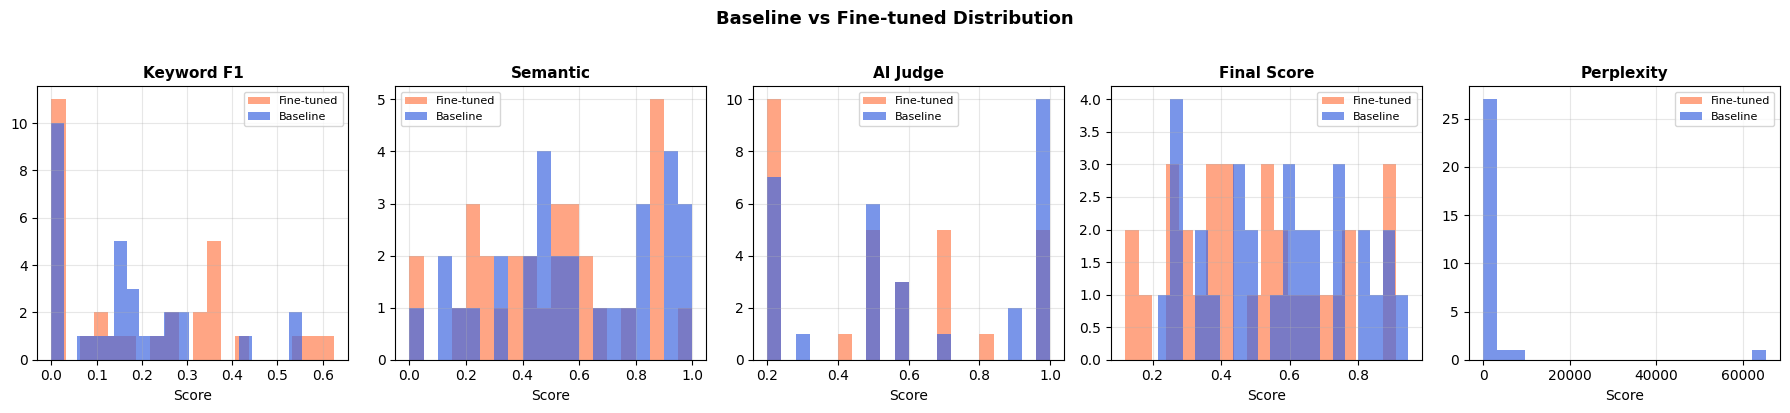

In [9]:
import matplotlib.pyplot as plt

# Load baseline if available
if os.path.exists("medical_baseline_results.csv"):
    base_df = pd.read_csv("medical_baseline_results.csv")
    has_baseline = True
else:
    has_baseline = False
    print("Run notebook 02 first to generate baseline results for the delta plot.")

metrics = [
    "keyword_score",
    "semantic_score",
    "ai_judge_score",
    "final_score",
    "perplexity",
]
labels = ["Keyword F1", "Semantic", "AI Judge", "Final Score", "Perplexity"]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
for ax, col, label in zip(axes, metrics, labels):
    vals_ft = results_df[col]
    ax.hist(vals_ft, bins=20, alpha=0.7, color="coral", label="Fine-tuned")
    if has_baseline and col in base_df.columns:
        ax.hist(base_df[col], bins=20, alpha=0.7, color="royalblue", label="Baseline")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Score")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Baseline vs Fine-tuned Distribution", y=1.02, fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("final_evaluation_distributions.png", dpi=150, bbox_inches="tight")
plt.show()